# Exploratory Data Analysis

## Libraries

In [1]:
from pathlib import Path
from typing import Union, Tuple, Dict, Any

import os
import numpy as np
import PIL
import SimpleITK as sitk
import gzip

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Getting rid of warnings
import warnings
warnings.filterwarnings("ignore")
sitk.ProcessObject.SetGlobalWarningDisplay(False)

## Configuration

In [2]:
# train and test data
training_data = os.path.join(os.getcwd(), "input", "training")
testing_data = os.path.join(os.getcwd(), "input", "testing")

## Helper Functions

In [3]:
def display_content(base_path, patient_id):
    """
    Displays the content of a patient's folder.

    Constructs the folder name using the patient ID and lists all files 
    contained within that directory if it exists.

    Args:
        base_path (str): The root directory path containing the patient folders.
        patient_id (int): The unique integer identifier of the patient (will be formatted as 'patientXXX').
    """
    patient_folder = f"patient{patient_id:03d}"
    full_path = os.path.join(base_path, patient_folder)
    
    if os.path.exists(full_path):
        files = os.listdir(full_path)
        print(f"Contents of {patient_folder}:")
        for f in files:
            print(f" - {f}")
    else:
        print(f"Error: Path not found - {full_path}")

def display_patient_metadata(base_path, patient_id):
    """
    Reads and displays specific metadata files for a patient.

    Scans the patient's directory for configuration (.cfg) and markdown (.md) 
    files, and prints their contents with formatted headers.

    Args:
        base_path (str): The root directory path containing the patient folders.
        patient_id (int): The unique integer identifier of the patient.
    """
    patient_folder = f"patient{patient_id:03d}"
    full_path = os.path.join(base_path, patient_folder)

    if not os.path.exists(full_path):
        print(f"Error: Path not found - {full_path}")
        return

    files = sorted([f for f in os.listdir(full_path) if f.endswith(('.cfg', '.md'))])
    
    if not files:
        print(f"No metadata (.cfg or .md) found in {patient_folder}")
        return

    for filename in files:
        file_path = os.path.join(full_path, filename)
        
        label = "CONFIG" if filename.endswith('.cfg') else "MARKDOWN"
        
        try:
            with open(file_path, 'r') as f:
                content = f.read()
            
            # Clear visual separation
            print(f"\n--- {label}: {filename} ---")
            print(content.strip())
            print("-" * 30)
            
        except Exception as e:
            print(f"Error reading {filename}: {e}")

def sitk_load(filepath: Union[str, Path]) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Loads an image using SimpleITK and returns the image and its metadata.
    """
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None, None

    # Load image
    image = sitk.ReadImage(str(filepath))
    
    # Extract metadata
    info = {
        "origin": image.GetOrigin(), 
        "spacing": image.GetSpacing(), 
        "direction": image.GetDirection()
    }

    # Extract numpy array (SimpleITK order is x,y,z -> numpy is z,y,x)
    im_array = np.squeeze(sitk.GetArrayFromImage(image))

    return im_array, info

def visualize_patient_data(base_path, patient_id):
    """
    Automatically finds and visualizes all .nii.gz files for a given patient.
    
    It categorizes files based on their type:
    - 3D Images (Frame XX)
    - 3D Ground Truths (Segmentation Masks)
    - 4D Sequences (Videos)
    """
    patient_folder = f"patient{patient_id:03d}"
    full_path = os.path.join(base_path, patient_folder)
    
    if not os.path.exists(full_path):
        print(f"Error: Path not found - {full_path}")
        return

    # Find all .nii.gz files and sort them to keep pairs (image & gt) together
    files = sorted([f for f in os.listdir(full_path) if f.endswith('.nii.gz')])
    
    if not files:
        print(f"No .nii.gz files found for {patient_folder}")
        return

    print(f"--- Visualizing Data for {patient_folder} ---")

    for filename in files:
        file_path = os.path.join(full_path, filename)
        
        # Load the file
        img, info = sitk_load(file_path)
        if img is None: continue

        # Check dimensions
        ndim = img.ndim
        
        # --- Visualization Logic ---
        if ndim == 3:
            num_slices = img.shape[0]
            mid_slice = num_slices // 2
            
            # Determine title based on filename (Check if it is Ground Truth)
            is_gt = "_gt" in filename
            title = f"{filename} (Ground Truth)" if is_gt else f"{filename} (Ultrasound Frame)"
            cmap = 'jet' if is_gt else 'gray' # Use different color for masks
            
            plt.figure(figsize=(5, 5))
            plt.imshow(img[mid_slice], cmap=cmap)
            plt.title(title)
            plt.axis('off')
            plt.show()

        elif ndim == 4:
            num_frames, num_slices, h, w = img.shape
            mid_slice = num_slices // 2
            
            print(f"Generating animation for {filename} ({num_frames} frames)...")
            
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.axis('off')
            im_display = ax.imshow(img[0][mid_slice], cmap='gray')
            ax.set_title(f"{filename} (4D Sequence)")

            def update(i):
                im_display.set_array(img[i][mid_slice])
                return [im_display]

            anim = FuncAnimation(fig, update, frames=num_frames, interval=80, blit=True)
            plt.close()
            display(HTML(anim.to_jshtml()))
            
        print("_" * 50)

## What do we have in our data?

In [4]:
display_content(training_data, 1)

Contents of patient001:
 - Info.cfg
 - patient001_frame01.nii.gz
 - MANDATORY_CITATION.md
 - patient001_frame12.nii.gz
 - patient001_frame12_gt.nii.gz
 - patient001_frame01_gt.nii.gz
 - patient001_4d.nii.gz


In [5]:
# .cfg      configuration
# .nii.gz   neuroimaging informatics technology initiative as gzip compression
# .md       markdown

In [6]:
display_content(training_data, 3)

Contents of patient003:
 - Info.cfg
 - patient003_frame15.nii.gz
 - patient003_frame01.nii.gz
 - MANDATORY_CITATION.md
 - patient003_4d.nii.gz
 - patient003_frame01_gt.nii.gz
 - patient003_frame15_gt.nii.gz


In [7]:
# patient001 has frame01 and frame12
# patient003 has frame01 and frame15

# different patients have different numbers after "frame"

In [8]:
display_content(testing_data, 101)

Contents of patient101:
 - Info.cfg
 - patient101_4d.nii.gz
 - MANDATORY_CITATION.md
 - patient101_frame01.nii.gz
 - patient101_frame14_gt.nii.gz
 - patient101_frame14.nii.gz
 - patient101_frame01_gt.nii.gz


In [9]:
display_content(testing_data, 103)

Contents of patient103:
 - Info.cfg
 - patient103_frame01.nii.gz
 - patient103_frame11_gt.nii.gz
 - patient103_frame11.nii.gz
 - MANDATORY_CITATION.md
 - patient103_frame01_gt.nii.gz
 - patient103_4d.nii.gz


In [10]:
# Same things apply for the test data

### Info.cfg & MANDATORY_CITATION.md

In [11]:
display_patient_metadata(training_data, 1)


--- CONFIG: Info.cfg ---
ED: 1
ES: 12
Group: DCM
Height: 184.0
NbFrame: 30
Weight: 95.0
------------------------------

--- MARKDOWN: MANDATORY_CITATION.md ---
You have to refer to this citation for any use of the ACDC database

O. Bernard, A. Lalande, C. Zotti, F. Cervenansky, et al.
"Deep Learning Techniques for Automatic MRI Cardiac Multi-structures Segmentation and Diagnosis: Is the Problem Solved ?" in IEEE Transactions on Medical Imaging, vol. 37, no. 11, pp. 2514-2525, Nov. 2018
doi: 10.1109/TMI.2018.2837502
------------------------------


### framexx.nii.gz

--- Visualizing Data for patient013 ---
Generating animation for patient013_4d.nii.gz (30 frames)...


__________________________________________________


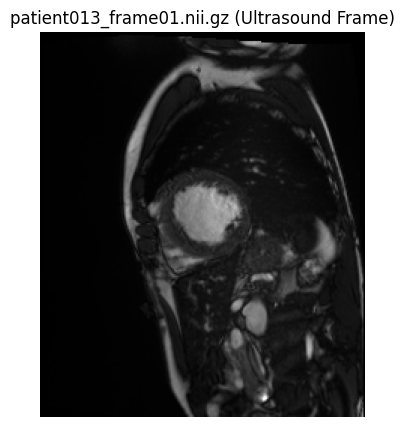

__________________________________________________


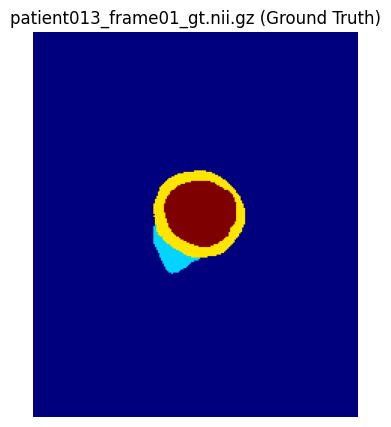

__________________________________________________


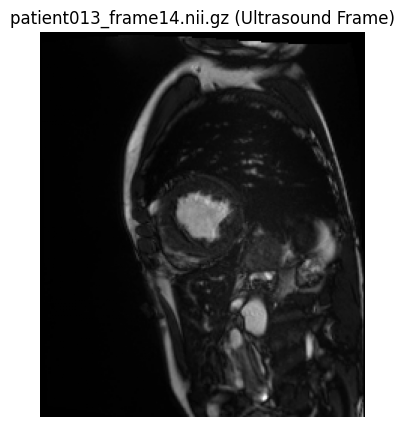

__________________________________________________


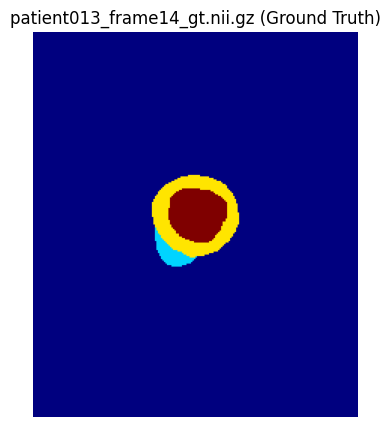

__________________________________________________


In [12]:
# Visualize everything for Patient 1
visualize_patient_data(training_data,13)

In [13]:
# gt stands for "ground truth"